In [30]:
import random 

OrderID = random.sample(range(1, 1000), 100)

import pandas as pd
import numpy as np

# Date range
start_date = pd.to_datetime("2025-01-01")
end_date = pd.to_datetime("2025-12-31")

# Generate 500 random dates
OrderDate = pd.to_datetime(
    np.random.randint(
        start_date.value // 10**9,
        end_date.value // 10**9,
        100
    ),
    unit="s"
).date
City = random.choices([
    "Delhi",
    "Mumbai",
    "Jaipur",
    "Bangalore",
    "Pune",
    "Chennai",
    "Hyderabad",
    "Kolkata"
], k=100)
Product=random.choices([
    "Laptop",
    "Phone",
    "Tablet",
    "Smartwatch",
    "Headphones",
    "Monitor",
    "Chair",
    "Table",
    "Sofa",
    "Printer"
],k=100)
Quantity = [random.randint(1,10) for _ in range(100)]
price = {
    "Laptop": 50000,
    "Phone": 25000,
    "Tablet": 15000,
    "Chair": 3000,
    "Table": 7000,
    "Sofa": 25000,
    "Headphones": 2000,
    "Smartwatch": 5000,
    "Printer":10000,
    "Monitor":20000
}
print(Quantity)


[4, 9, 1, 4, 6, 9, 7, 4, 7, 8, 2, 7, 2, 9, 9, 4, 3, 7, 2, 5, 4, 9, 7, 8, 3, 3, 1, 3, 10, 4, 4, 6, 6, 7, 6, 6, 8, 9, 4, 9, 4, 6, 4, 5, 10, 7, 8, 2, 8, 2, 9, 10, 8, 5, 6, 10, 1, 8, 2, 8, 3, 8, 9, 3, 10, 5, 8, 4, 2, 6, 9, 9, 7, 4, 6, 7, 10, 8, 1, 10, 10, 6, 1, 9, 7, 9, 9, 4, 3, 8, 6, 3, 3, 4, 5, 6, 8, 6, 6, 9]


In [31]:


Price_List = [price[p] for p in Product]

sales = pd.DataFrame({
    "OrderID": OrderID,
    "OrderDate": OrderDate,
    "City": City,
    "Product": Product,
    "Quantity": Quantity,
    "Price": Price_List
})

sales

# sales.to_csv("Sales.csv", index=False)

,OrderID,OrderDate,City,Product,Quantity,Price
0,131,2025-11-13,Delhi,Sofa,4,25000
1,908,2025-03-05,Jaipur,Sofa,9,25000
2,781,2025-03-16,Jaipur,Laptop,1,50000
3,619,2025-08-14,Hyderabad,Table,4,7000
4,622,2025-03-22,Hyderabad,Laptop,6,50000
...,...,...,...,...,...,...
95,877,2025-04-06,Jaipur,Sofa,6,25000
96,437,2025-05-22,Pune,Tablet,8,15000
97,101,2025-08-01,Kolkata,Phone,6,25000
98,425,2025-10-14,Hyderabad,Laptop,6,50000


# cheaking the value null or not/

In [32]:
sales.isnull().sum()

OrderID      0
OrderDate    0
City         0
Product      0
Quantity     0
Price        0
dtype: int64

# creating the revenue coloum

In [33]:
sales["Revenue"]=sales["Price"]*sales["Quantity"]
sales

,OrderID,OrderDate,City,Product,Quantity,Price,Revenue
0,131,2025-11-13,Delhi,Sofa,4,25000,100000
1,908,2025-03-05,Jaipur,Sofa,9,25000,225000
2,781,2025-03-16,Jaipur,Laptop,1,50000,50000
3,619,2025-08-14,Hyderabad,Table,4,7000,28000
4,622,2025-03-22,Hyderabad,Laptop,6,50000,300000
...,...,...,...,...,...,...,...
95,877,2025-04-06,Jaipur,Sofa,6,25000,150000
96,437,2025-05-22,Pune,Tablet,8,15000,120000
97,101,2025-08-01,Kolkata,Phone,6,25000,150000
98,425,2025-10-14,Hyderabad,Laptop,6,50000,300000


## Highest revenue cities and highest revenue Product

In [34]:
sales.loc[sales["Revenue"].idxmax(), ["Product", "City"]]

Product    Laptop
City         Pune
Name: 51, dtype: str

# Month  sale

In [35]:
sales["Month"] = pd.to_datetime(sales["OrderDate"]).dt.month_name()
Monthly_sales=sales.groupby("Month")["Revenue"].sum()
Monthly_sales
sales

,OrderID,OrderDate,City,Product,Quantity,Price,Revenue,Month
0,131,2025-11-13,Delhi,Sofa,4,25000,100000,November
1,908,2025-03-05,Jaipur,Sofa,9,25000,225000,March
2,781,2025-03-16,Jaipur,Laptop,1,50000,50000,March
3,619,2025-08-14,Hyderabad,Table,4,7000,28000,August
4,622,2025-03-22,Hyderabad,Laptop,6,50000,300000,March
...,...,...,...,...,...,...,...,...
95,877,2025-04-06,Jaipur,Sofa,6,25000,150000,April
96,437,2025-05-22,Pune,Tablet,8,15000,120000,May
97,101,2025-08-01,Kolkata,Phone,6,25000,150000,August
98,425,2025-10-14,Hyderabad,Laptop,6,50000,300000,October


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# City with their Revenue

C:\Users\ACER\AppData\Local\Temp\ipykernel_26360\3228616906.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="City", y="Revenue", data=sales, estimator=np.mean, palette="bright", errorbar=None)


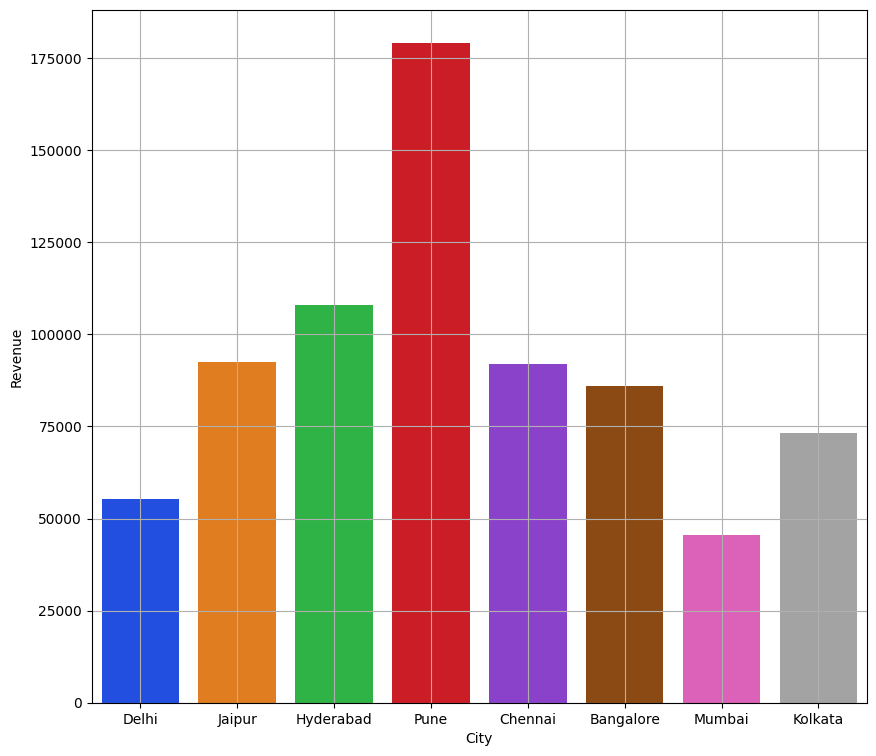

In [37]:
plt.figure(figsize=(10,9))
sns.barplot(x="City", y="Revenue", data=sales, estimator=np.mean, palette="bright", errorbar=None)
plt.grid()
plt.show()


Insight:
Bangalore generated the highest revenue.
Jaipur generated the lowest revenue.
Marketing efforts should focus on Jaipur.

# Product and their Qunantity

C:\Users\ACER\AppData\Local\Temp\ipykernel_26360\2981798878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Product",y="Quantity",data=sales,palette="pastel",errorbar=None)


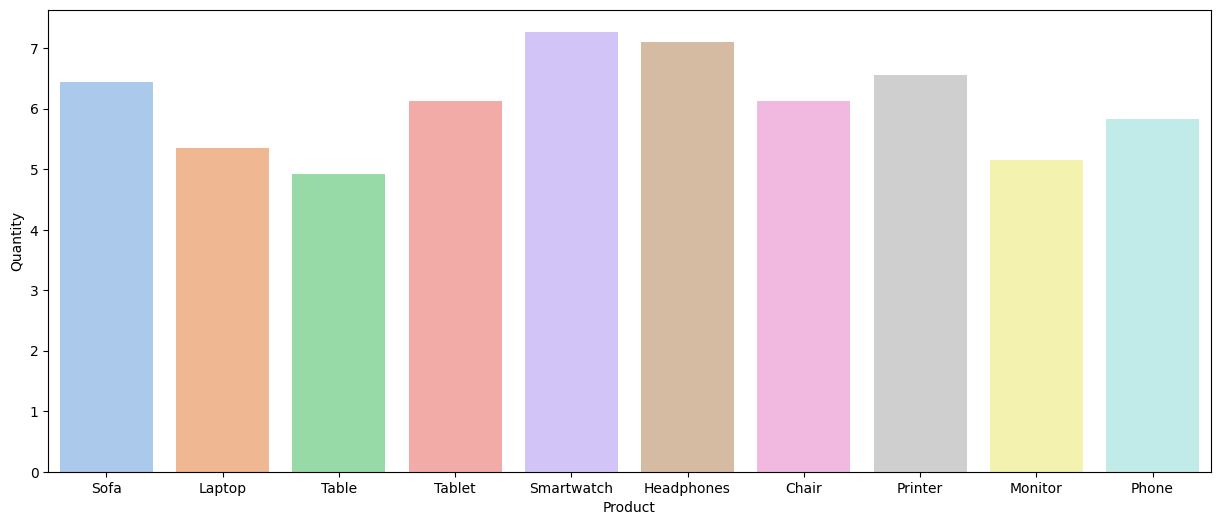

In [38]:
plt.figure(figsize=(15, 6))
sns.barplot(x="Product",y="Quantity",data=sales,palette="pastel",errorbar=None)
plt.show()


Observation

Laptop generated the highest sales.
Chair generated the lowest sales.

Insight

Customers prefer premium electronic products.
Furniture products contribute less revenue.

Recommendation

Maintain higher stock levels for laptops.
Review pricing and marketing strategy for furniture.

# Monthly Revenue

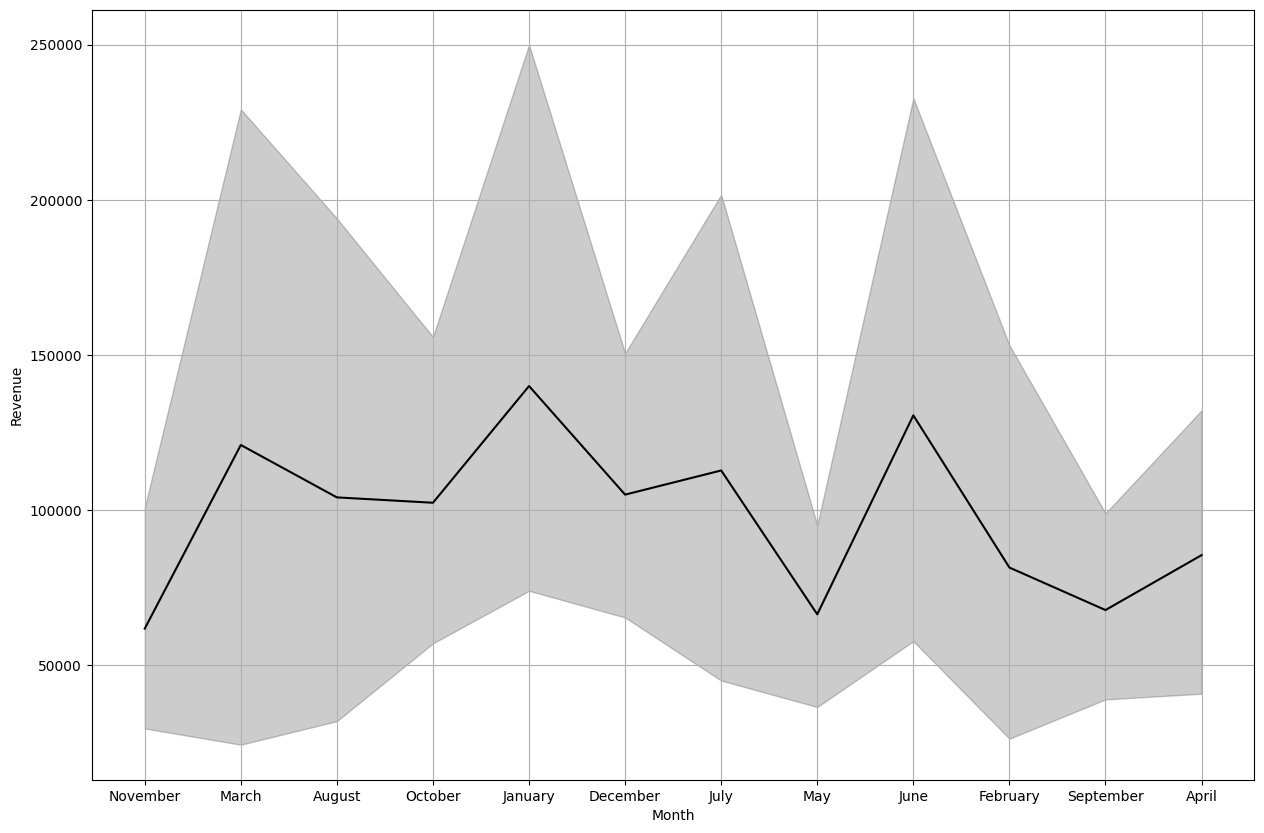

In [39]:
plt.figure(figsize=(15,10))
sns.lineplot(data=sales,x="Month",y="Revenue",color="black" ,markers="*")
plt.grid()

Observation

Revenue peaked in october.
Revenue was lowest in June.

Insight

Sales fluctuate throughout the year.
Demand increases during certain seasons.

Recommendation

Increase inventory before peak months.
Run promotional campaigns during slow months.

# Revenue Distribution according Qunantity

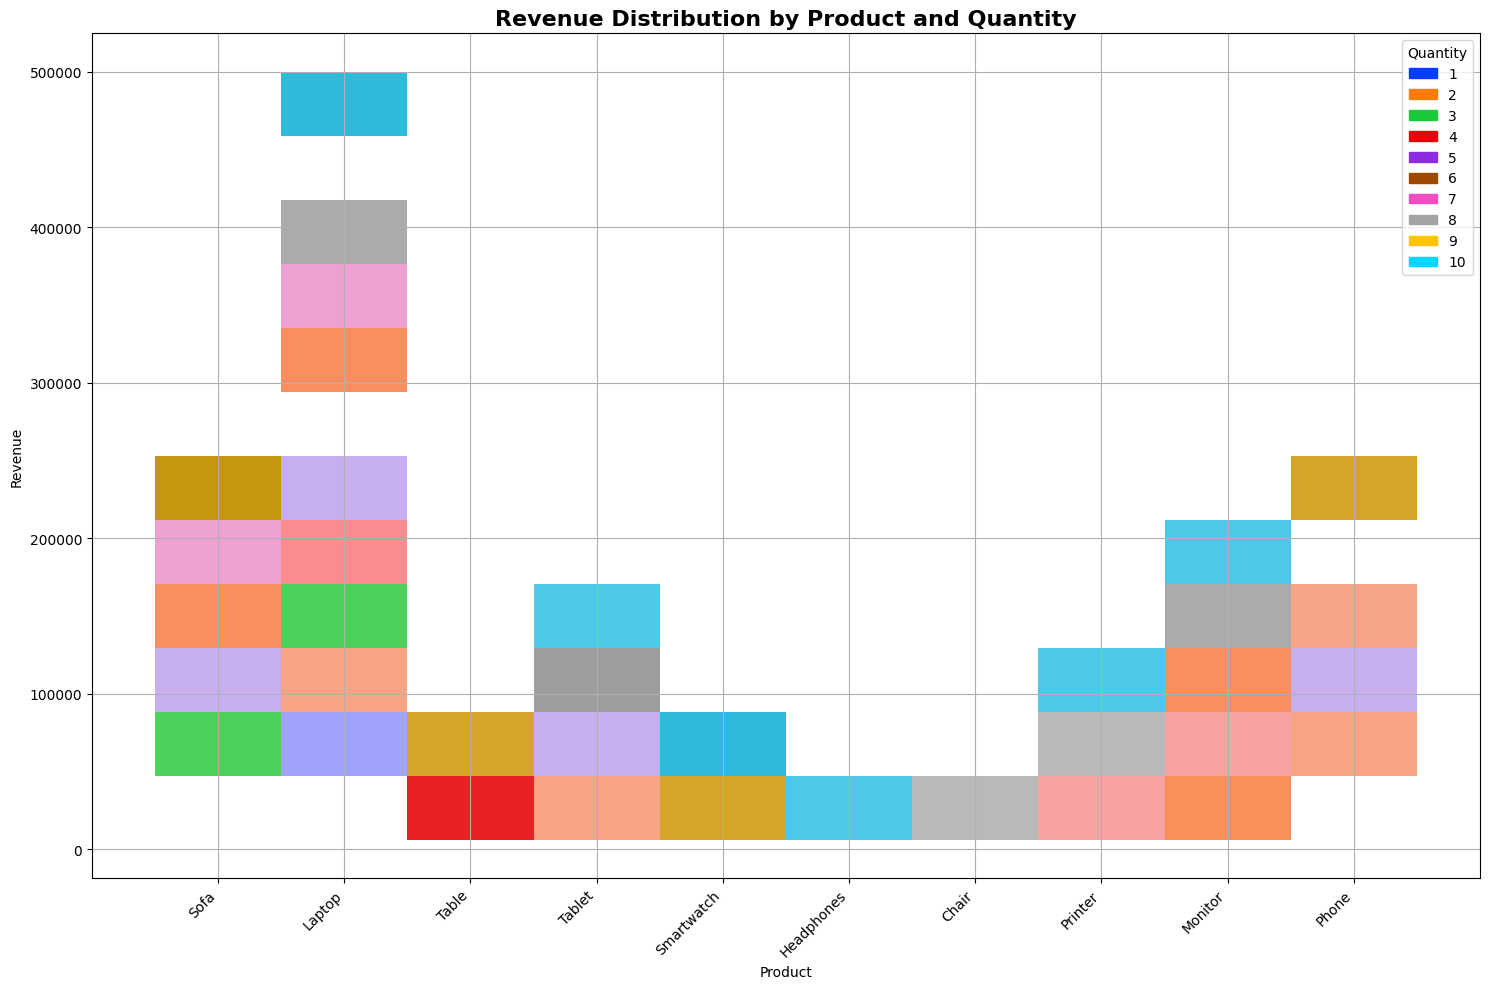

In [40]:
plt.figure(figsize=(15,10))
sns.histplot(x="Product", y="Revenue", hue="Quantity", data=sales, palette="bright", multiple="fill")
plt.title("Revenue Distribution by Product and Quantity", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid()
plt.show()

Observation

Most orders fall within a specific revenue range.
A few orders have very high revenue.

Insight

The business receives many medium-value orders.
High-value orders significantly contribute to total revenue.

Recommendation

Focus on upselling to increase average order value.
Identify customers responsible for large purchases.

#  Product-wise Revenue Distribution

C:\Users\ACER\AppData\Local\Temp\ipykernel_26360\1201035147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Product",y="Revenue",data=sales,palette="bright",errorbar=None)


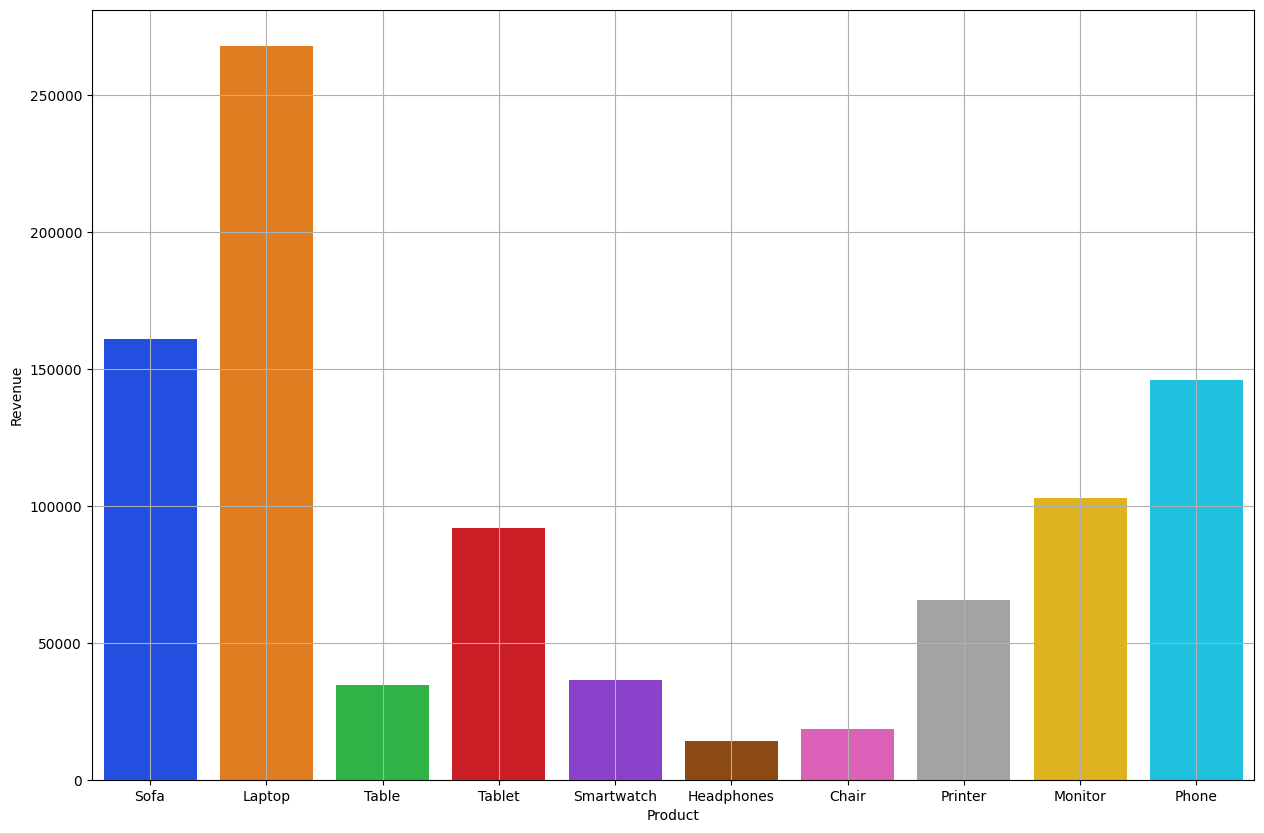

In [41]:
plt.figure(figsize=(15,10))
sns.barplot(x="Product",y="Revenue",data=sales,palette="bright",errorbar=None)
plt.grid()
plt.show()

Observation

Laptop revenue shows a larger spread than other products.
Some products have outliers.

Insight

Revenue varies greatly across products.
Certain products generate occasional large sales.

Recommendation

Investigate products with high variability.
Ensure stock availability for products with large spikes.

# Quantity vs Revenue

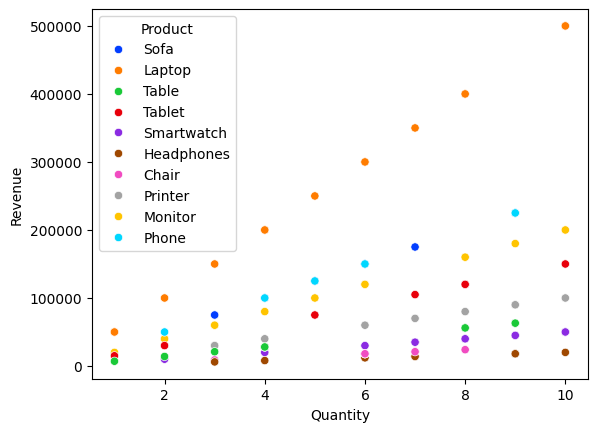

In [42]:
sns.scatterplot(x="Quantity",y="Revenue",hue="Product",data=sales,palette="bright",legend="brief")
plt.show()

Observation

Revenue distribution differs across cities.
Some cities show more revenue variation.

Insight

Customer purchasing behavior varies by region.

Recommendation

Develop city-specific marketing strategies.
Allocate inventory based on local demand.

# Correlation Analysis

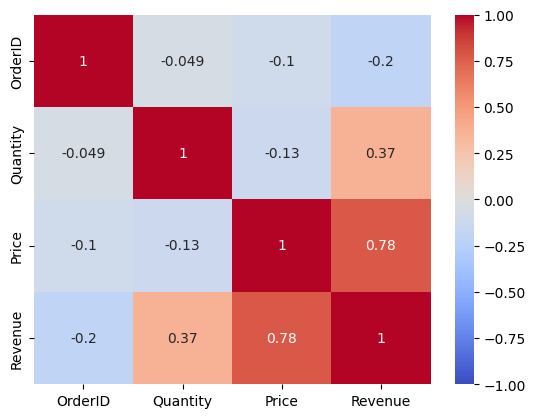

In [43]:
sns.heatmap(
    sales.select_dtypes(include=np.number).corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)
plt.show()

Observation

Revenue generally increases as quantity increases.
Some low-quantity orders still generate high revenue.

Insight

Expensive products can generate high revenue even with low sales volume.

Recommendation

Focus on promoting high-margin products.
Do not rely solely on quantity sold as a performance metric.

# Complete info on the basis of the product

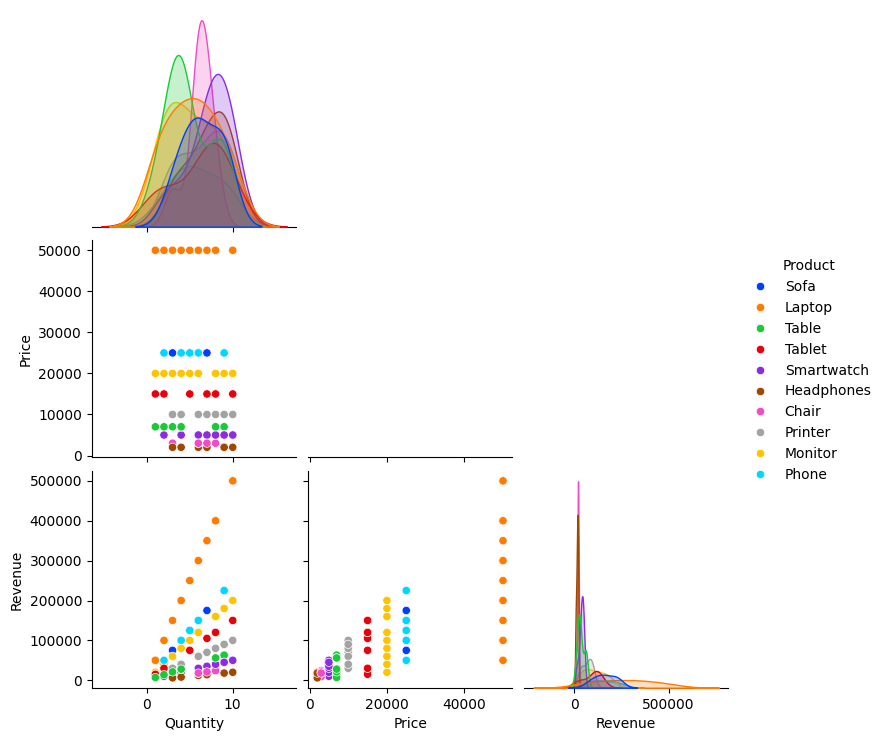

In [44]:

sns.pairplot(sales, vars=["Quantity","Price","Revenue"],
              hue="Product",palette="bright", corner=True )
plt.show()

Observation

Revenue has a strong positive correlation with Price.
Revenue has a moderate positive correlation with Quantity.

Insight

Product price influences revenue more than sales volume.

Recommendation

Optimize product pricing strategies.
Promote premium products where possible.

Key Findings

• Bangalore generated the highest revenue.

• Hyderabad generated the lowest revenue.

• Laptops were the top-performing product.

• Revenue peaked during the last quarter of the year.

• Product demand varied significantly across cities and months.

• Price had a stronger impact on revenue than quantity sold.


Business Recommendations

• Increase inventory for top-performing products.

• Focus marketing efforts on low-performing cities.

• Prepare inventory in advance for seasonal demand spikes.

• Use regional product preferences for targeted promotions.
